In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Generate sample data with volatility shift
np.random.seed(42)
dates = pd.date_range('2024-01-01', periods=200, freq='D')

# Low volatility period then high volatility period
low_vol = np.random.normal(100, 2, 100)  # mean=100, std=2
high_vol = np.random.normal(100, 8, 100)  # mean=100, std=8
data = np.concatenate([low_vol, high_vol])

df = pd.DataFrame({'value': data}, index=dates)

display(df)

,value
2024-01-01,100.993428
2024-01-02,99.723471
2024-01-03,101.295377
2024-01-04,103.046060
2024-01-05,99.531693
...,...
2024-07-14,103.082539
2024-07-15,92.929141
2024-07-16,101.229801
2024-07-17,100.465670


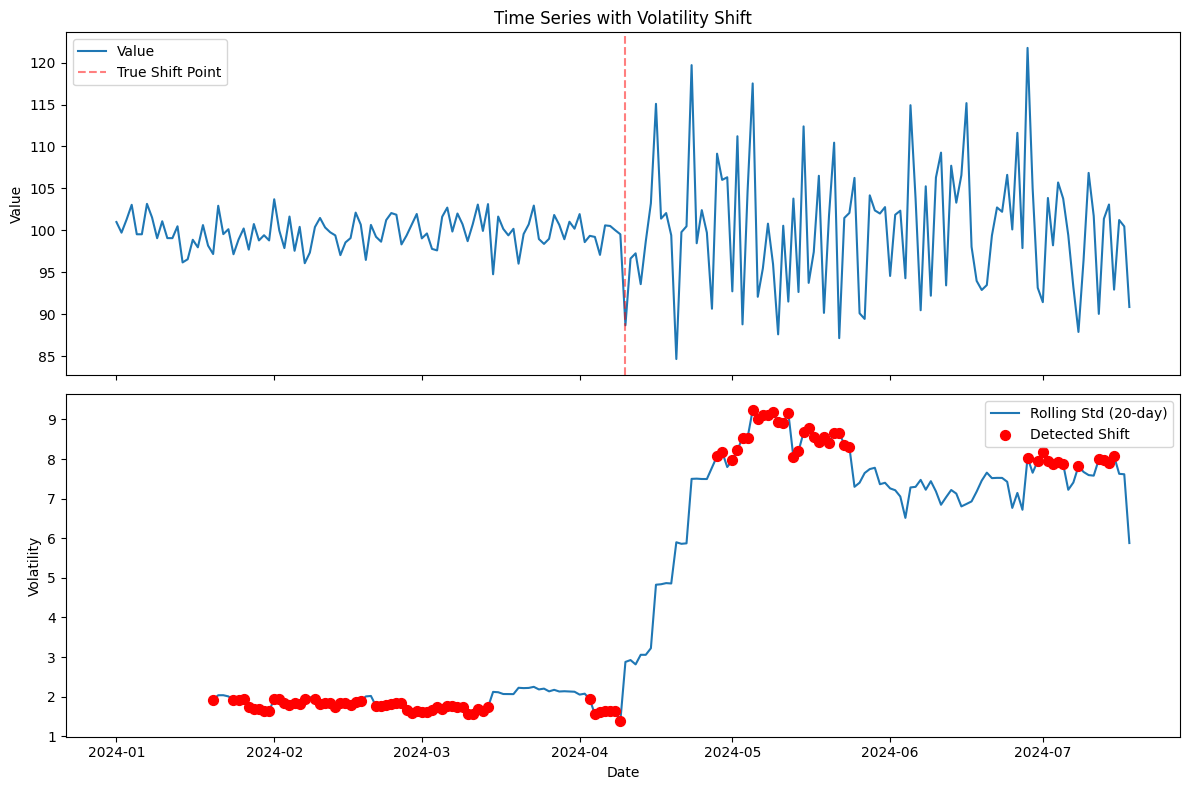

Shift detected around: 2024-01-20 00:00:00

Volatility stats:
Pre-shift avg std: 1.86
Post-shift avg std: 7.33


In [3]:
# Detect volatility shift
df['rolling_std'] = df['value'].rolling(window=20).std()
df['volatility_zscore'] = (df['rolling_std'] - df['rolling_std'].mean()) / df['rolling_std'].std()

# Flag significant shifts (z-score > 1)
df['volatility_shift'] = df['volatility_zscore'].abs() > 1

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.plot(df.index, df['value'], label='Value')
ax1.axvline(x=dates[100], color='red', linestyle='--', alpha=0.5, label='True Shift Point')
ax1.set_ylabel('Value')
ax1.legend()
ax1.set_title('Time Series with Volatility Shift')

ax2.plot(df.index, df['rolling_std'], label='Rolling Std (20-day)')
ax2.scatter(df[df['volatility_shift']].index, 
            df[df['volatility_shift']]['rolling_std'], 
            color='red', s=50, label='Detected Shift', zorder=5)
ax2.set_ylabel('Volatility')
ax2.set_xlabel('Date')
ax2.legend()

plt.tight_layout()
plt.show()

shift_points = df[df['volatility_shift']]
if not shift_points.empty:
    print(f"Shift detected around: {shift_points.index[0]}")
else:
    print("No volatility shift detected with current threshold.")
print(f"\nVolatility stats:")
print(f"Pre-shift avg std: {df['rolling_std'][:100].mean():.2f}")
print(f"Post-shift avg std: {df['rolling_std'][100:].mean():.2f}")

In [4]:
# Generate sample data with volatility shifts
np.random.seed(42)
dates = pd.date_range('2024-01-01', periods=300, freq='D')

# Low -> High -> Low volatility periods
low_vol_1 = np.random.normal(100, 2, 100)   # mean=100, std=2
high_vol = np.random.normal(100, 8, 100)    # mean=100, std=8
low_vol_2 = np.random.normal(100, 2, 100)   # mean=100, std=2
data = np.concatenate([low_vol_1, high_vol, low_vol_2])

df = pd.DataFrame({'value': data}, index=dates)

display(df)

,value
2024-01-01,100.993428
2024-01-02,99.723471
2024-01-03,101.295377
2024-01-04,103.046060
2024-01-05,99.531693
...,...
2024-10-22,98.614181
2024-10-23,101.799200
2024-10-24,100.614599
2024-10-25,101.625724


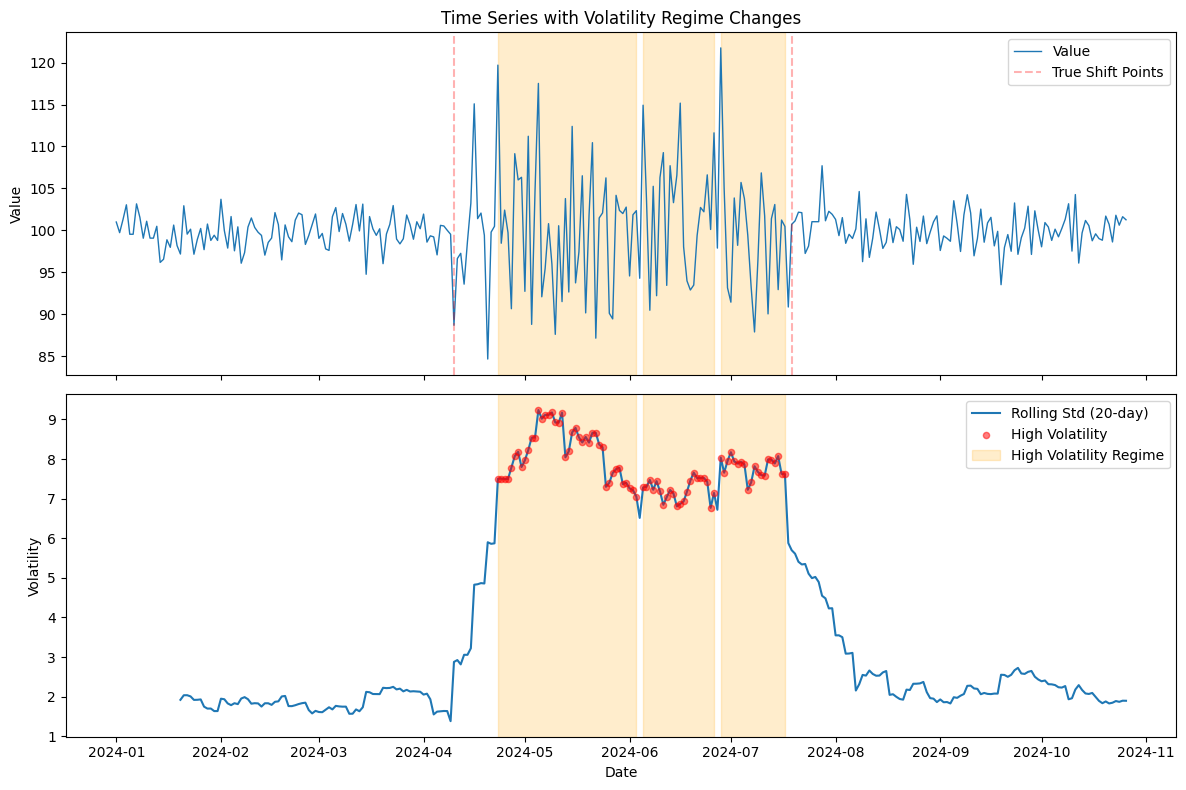

Detected high volatility periods:
  2024-04-23 to 2024-06-03 (42 days)
  2024-06-05 to 2024-06-26 (22 days)
  2024-06-28 to 2024-07-17 (20 days)

Volatility stats:
Period 1 (low) avg std: 1.86
Period 2 (high) avg std: 7.33
Period 3 (low) avg std: 2.63


In [5]:
# Detect volatility shift
df['rolling_std'] = df['value'].rolling(window=20).std()
df['volatility_zscore'] = (df['rolling_std'] - df['rolling_std'].mean()) / df['rolling_std'].std()

# Flag significant shifts (z-score > 1)
df['high_volatility'] = df['volatility_zscore'] > 1

# Find consecutive high volatility periods
df['volatility_regime'] = (df['high_volatility'] != df['high_volatility'].shift()).cumsum()
high_vol_periods = df[df['high_volatility']].groupby('volatility_regime')

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Top plot - time series with shaded regions
ax1.plot(df.index, df['value'], label='Value', linewidth=1)
ax1.axvline(x=dates[100], color='red', linestyle='--', alpha=0.3, label='True Shift Points')
ax1.axvline(x=dates[200], color='red', linestyle='--', alpha=0.3)

# Shade high volatility periods
for _, period in high_vol_periods:
    if len(period) > 5:  # Only shade if period is significant
        ax1.axvspan(period.index[0], period.index[-1], alpha=0.2, color='orange')

ax1.set_ylabel('Value')
ax1.legend()
ax1.set_title('Time Series with Volatility Regime Changes')

# Bottom plot - rolling std with shaded regions
ax2.plot(df.index, df['rolling_std'], label='Rolling Std (20-day)', linewidth=1.5)
ax2.scatter(df[df['high_volatility']].index, 
            df[df['high_volatility']]['rolling_std'], 
            color='red', s=20, alpha=0.5, label='High Volatility', zorder=5)

# Shade high volatility periods
for _, period in high_vol_periods:
    if len(period) > 5:
        ax2.axvspan(period.index[0], period.index[-1], alpha=0.2, color='orange', 
                    label='High Volatility Regime' if _ == list(high_vol_periods.groups.keys())[0] else '')

ax2.set_ylabel('Volatility')
ax2.set_xlabel('Date')
ax2.legend()

plt.tight_layout()
plt.show()

# Print detected regimes
print("Detected high volatility periods:")
for regime_id, period in high_vol_periods:
    if len(period) > 5:
        print(f"  {period.index[0].date()} to {period.index[-1].date()} ({len(period)} days)")

print(f"\nVolatility stats:")
print(f"Period 1 (low) avg std: {df['rolling_std'][:100].mean():.2f}")
print(f"Period 2 (high) avg std: {df['rolling_std'][100:200].mean():.2f}")
print(f"Period 3 (low) avg std: {df['rolling_std'][200:].mean():.2f}")